In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
from make import load_secondary_data, load_heath_assessment_test_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [4]:
valid_spec, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [5]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [6]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]  # (H, W) or (H, W, C)

        if arr.ndim == 3:
                arr = np.mean(arr, axis=-1)  # (H, W)

        # Ensure float32
        arr = arr.astype(np.float32)

        # If not already in dB, convert. If it *is* already in dB, skip this block.
        #arr = np.maximum(arr, EPS)
        #arr_db = 10.0 * np.log10(arr)

        # Apply dynamic range floor and normalize to [0,1]
        arr = arr - arr.max()
        arr = np.clip(arr, FLOOR_DB, 0.0)
        arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

        arr_01 = arr_01.astype(np.float32)

        arr_01 = arr_01 ** 0.9

        arr_01 = np.flipud(arr_01)

        cmap = plt.get_cmap('magma')
        img_rgb = cmap(arr_01)[:, :, :3]


        # Convert to tensor and make 3-channel (grayscale -> RGB-style)
        t = torch.from_numpy(img_rgb)          # (H, W)
        t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

        # Add batch dimension for interpolate
        #t = t.unsqueeze(0)                    # (1, 3, H, W)

        # Resize
        t_resized = F.interpolate(
                t, size=TARGET_HW, mode='bilinear', align_corners=False
        )

        return TensorImage(t_resized.squeeze(0))  # (3, H, W)
def get_y(i):
    return all_labels[i]

In [7]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [8]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [9]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [10]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

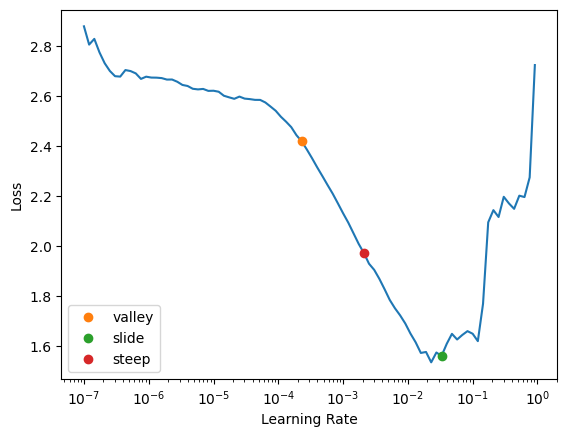

In [11]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [12]:
learner.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,time
0,0.964040,0.536101,0.833333,00:00


epoch,train_loss,valid_loss,accuracy,time
0,0.263649,0.291425,0.925000,00:00
1,0.193971,0.244338,0.925000,00:00
2,0.136572,0.253857,0.933333,00:00
3,0.082544,0.156657,0.950000,00:00
4,0.046008,0.117256,0.975000,00:00
5,0.025071,0.121688,0.950000,00:00
6,0.013589,0.101915,0.966667,00:00
7,0.007575,0.116905,0.941667,00:00
8,0.004443,0.120527,0.950000,00:00
9,0.002764,0.105878,0.966667,00:00


In [13]:
learner.unfreeze()

In [14]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time


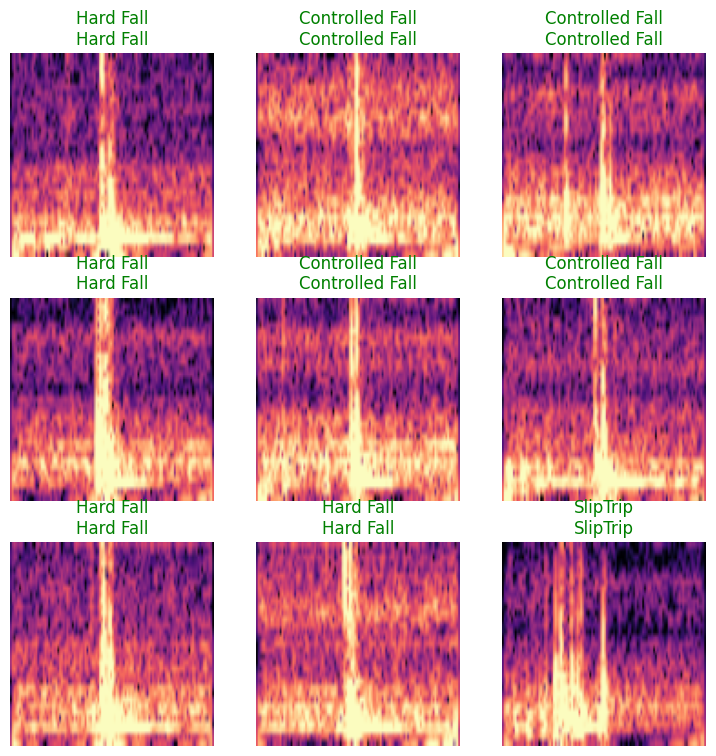

In [15]:
learner.show_results()

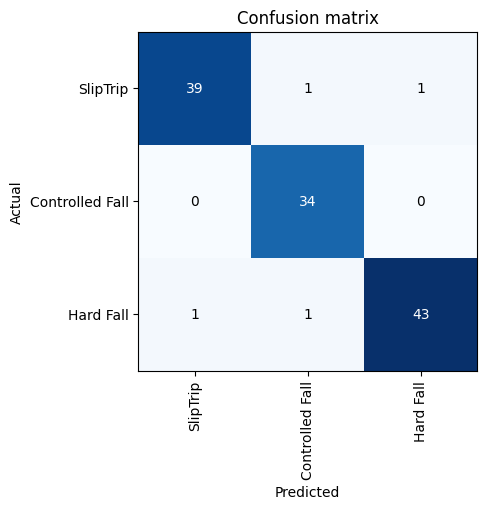

In [16]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [9]:
dir = Path('./models')

In [10]:
learner = load_learner(dir/'classic_cnn.pkl')

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [28]:
learner.path = dir

learner.export('classic_cnn.pkl')

TypeError: unsupported operand type(s) for /: 'builtin_function_or_method' and 'str'

In [17]:
def get_x_test(i):
    arr = valid_spec[i]

    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [18]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [20]:
len(valid_spec)

204

In [21]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [22]:
learner.validate()

(#2) [0.08624446392059326,0.9666666388511658]

In [44]:
count = 0
for i in range(len(y_test)):
    if y_test[i] == "SlipTrip" and y_test[i] == y_pred[i]:
        count += 1

print(count)

61


In [42]:
dls.vocab = ["Controlled Fall", "Hard Fall", "SlipTrip"]

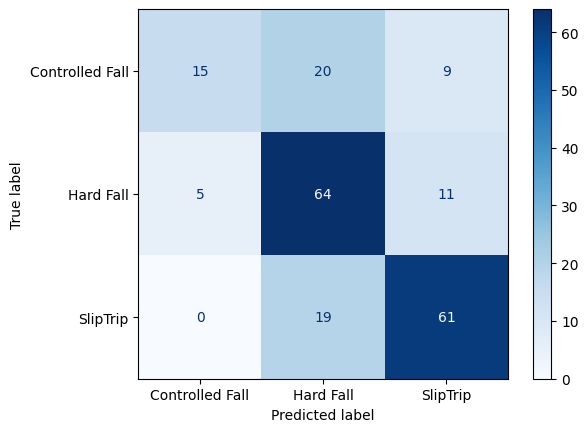

In [43]:
cm = confusion_matrix(y_test, y_pred, labels=["Controlled Fall", "Hard Fall", "SlipTrip"])
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [45]:
accuracy_score(y_test, y_pred)

0.6862745098039216

In [46]:
precision_score(y_test, y_pred, average='weighted')

0.7007629972761009

In [47]:
recall_score(y_test, y_pred, average="weighted")

0.6862745098039216

In [48]:
f1_score(y_test, y_pred, average="weighted")

0.6725607949285678